## UEFA Champions League 2021–2022 EDA

Research Question

To what extent is having top-performing players across attacking and defensive categories associated with how far a team advanced in the 2021–2022 UEFA Champions League?

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

In [49]:
team_summary = pd.read_csv(
    "/Users/nandjath/Desktop/PROJECT-UEFA/team_summary.csv"
)

team_summary.head()

,club,stage,advancement_score,Assists,Balls Recovered,Goals,Tackles Won,categories_represented,unique_top_players,total_top_player_observations,attacking_top_players,defensive_top_players
0,Real Madrid,Champion,6,2.0,5.0,3.0,6.0,4.0,10.0,16.0,5.0,11.0
1,Liverpool,Runner-up,5,1.0,6.0,4.0,3.0,4.0,10.0,14.0,5.0,9.0
2,Villarreal,Semifinal,4,3.0,6.0,1.0,4.0,4.0,9.0,14.0,4.0,10.0
3,Man. City,Semifinal,4,3.0,4.0,2.0,2.0,4.0,8.0,11.0,5.0,6.0
4,Atlético,Quarterfinal,3,0.0,2.0,1.0,5.0,3.0,5.0,8.0,1.0,7.0


In [50]:
#missing data
print("Teams:", len(team_summary))
print("Missing values:", team_summary.isnull().sum().sum())

Teams: 32
Missing values: 0


## Variable I selected which are four performance measures:

* Goals
* Assists

# attacking stats.

* Tackles won
* Balls recovered

# defensive stats.


Bampouras et al. (2012) emphasize that performance analysis should be grounded in the practical experience of professionals. This supports using real-world player performance data to investigate meaningful patterns in soccer.

A top performer was a player at or above the 90th percentile.

I then grouped the players by team.

categories_represented shows how many of the four categories were represented.

unique_top_players shows the number of distinct top performers.

advancement_score for how far each team went.

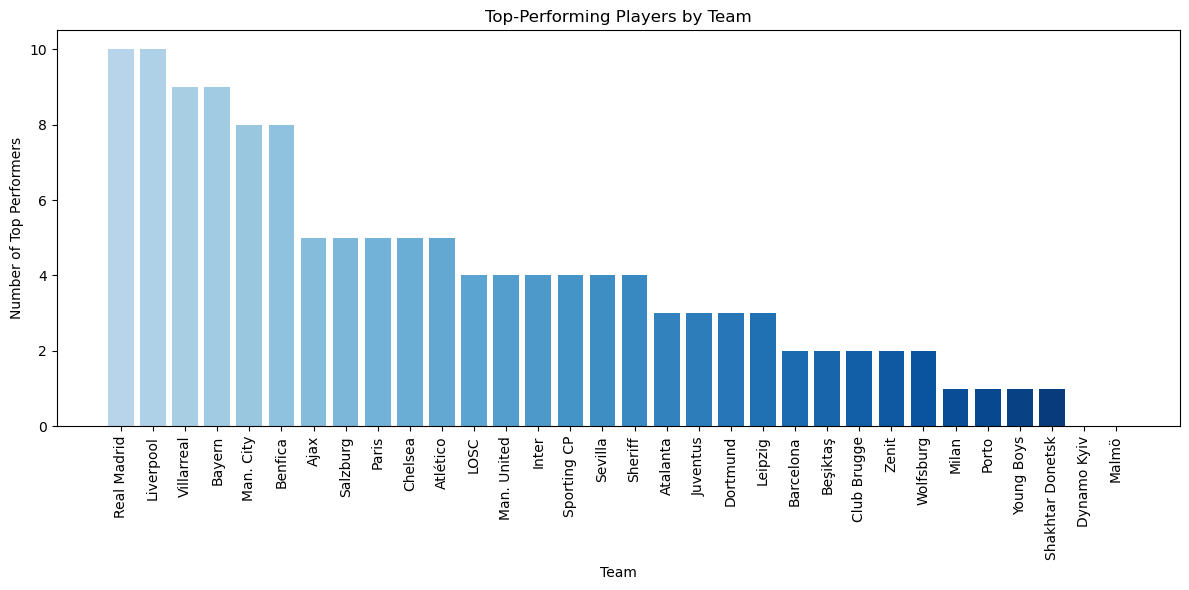

In [51]:
data = team_summary.sort_values(
    "unique_top_players",
    ascending=False
)

plt.figure(figsize=(12, 6))

colors = cm.Blues(
    np.linspace(0.3, 1, len(data))
)

plt.bar(
    data["club"],
    data["unique_top_players"],
    color=colors
)

plt.title("Top-Performing Players by Team")
plt.xlabel("Team")
plt.ylabel("Number of Top Performers")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

This Bar Plot chart compares the number of top-performing players across teams.

Real Madrid, Liverpool, Villarreal, Bayern and Manchester City have several top performers.

## Top-Performing Players and Tournament Advancement

This scatter plot examines the relationship between the number of unique top-performing players on a team and how far the team advanced in the tournament.

Each point represents one team.

Modric et al. (2022) measured team achievement in the UEFA Champions League using group-stage qualification, final group placement, and total group points. Their approach supports using tournament progression as a measure of team achievement.

### Advancement Score


1 = Group Stage  
2 = Round of 16  
3 = Quarterfinal  
4 = Semifinal  
5 = Runner-up  
6 = Champion

ps: Some points overlap because teams had the same values. The transparent points make the overlap easier to see.

Overall, teams with more top-performing players generally advanced further.

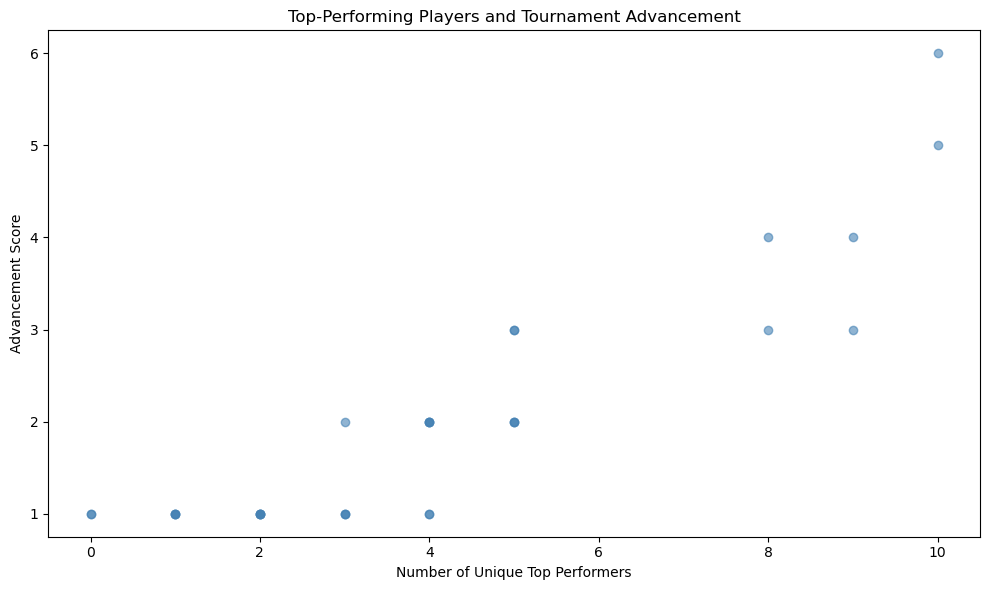

In [52]:
plt.figure(figsize=(10, 6))

plt.scatter(
    team_summary["unique_top_players"],
    team_summary["advancement_score"],
    color="steelblue",
    alpha=0.6
)

plt.title("Top-Performing Players and Tournament Advancement")
plt.xlabel("Number of Unique Top Performers")
plt.ylabel("Advancement Score")

plt.tight_layout()
plt.show()

### Attacking and Defensive Top Performers

This chart compares attacking and defensive top performers for each team. It shows how teams were represented in both areas of the game.


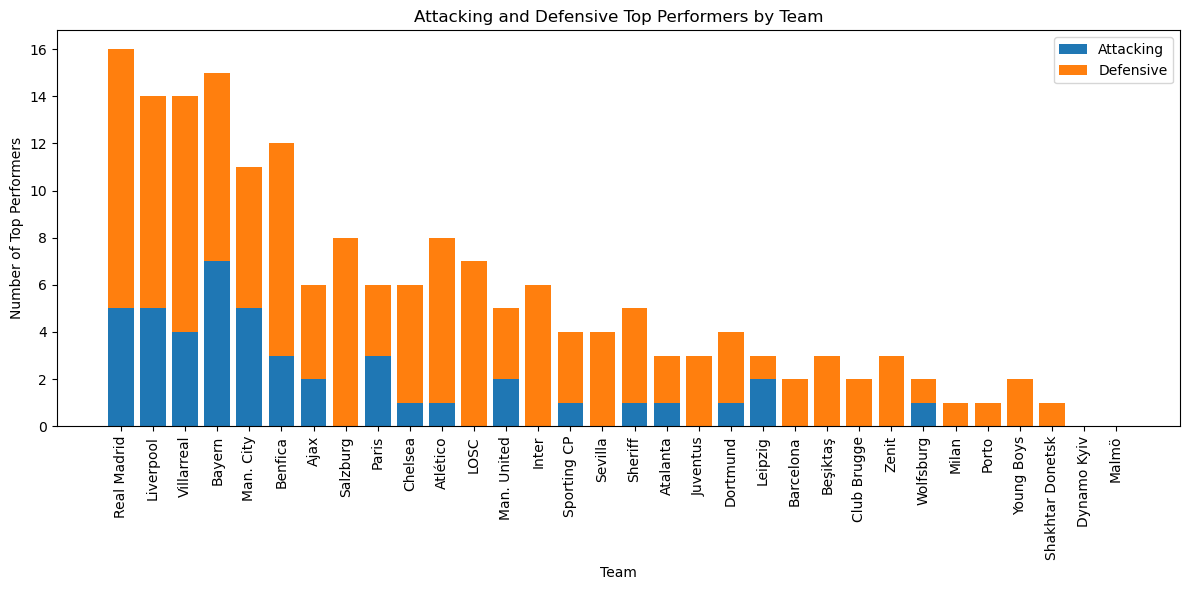

In [53]:
data = team_summary.sort_values(
    "unique_top_players",
    ascending=False
)

plt.figure(figsize=(12, 6))

plt.bar(
    data["club"],
    data["attacking_top_players"],
    label="Attacking"
)

plt.bar(
    data["club"],
    data["defensive_top_players"],
    bottom=data["attacking_top_players"],
    label="Defensive"
)

plt.title("Attacking and Defensive Top Performers by Team")
plt.xlabel("Team")
plt.ylabel("Number of Top Performers")
plt.xticks(rotation=90)
plt.legend()

plt.tight_layout()
plt.show()

## Findings

* **1st – Real Madrid:** 10 top-performing players and Champions League champion.
* **1st – Liverpool:** 10 top-performing players and runner-up.
* **3rd – Villarreal:** 9 top-performing players and semifinalist.
* **3rd – Bayern:** 9 top-performing players and quarterfinalist.
* **5th – Manchester City:** 8 top-performing players and semifinalist.

These results show a general association between having more top-performing players and advancing further.

However other factors may also affect tournament results which implies a sens of Correlation ≠ Causation!!.



## Limitations

* I only used one Champions League season.
* Player statistics do not include all factors that affect team performance.
* Playing time, injuries, tactics, and opponent strength may affect the results.
* Weather conditions and home or away games may also affect match performance.
* The 90th-percentile cutoff is one way to define top performers INDIVIDUALLY and only based on what factors I thought composed a top attacker and top defenders!!


## AI Transparency

I used VS Code and ChatGPT (GPT-5.6) to help fix some code syntax and improve the extra visualization showing teams with both attacking and defensive top-performing players.


## References

Bampouras, M. T., Cronin, C., & Miller, K. P. (2012). Performance analytic processes in elite sport practice: An exploratory investigation of the perspectives of a sport scientist, coach and athlete. International Journal of Performance Analysis in Sport, 12(2), 468–483. https://doi.org/10.1080/24748668.2012.11868611

ESPN Internet Ventures. (2022). UEFA Champions League Performance Stats, 2021-22 season. ESPN. https://www.espn.com/soccer/stats/_/league/UEFA.CHAMPIONS/view/performance/season/2021 

Modric, T., Versic, S., & Jelicic, M. (2022). Monitoring Technical Performance in the UEFA Champions League: Differences between successful and unsuccessful teams. Montenegrin Journal of Sports Science and Medicine. https://www.mjssm.me/?sekcija=article&artid=236 

Pearson, A., Webb, T., Barrow, C., Milligan, G., & Miller-Dicks, M. (2026). “What are we looking at?”: the development and implementation of a performance analysis framework for netball umpires. International Journal of Performance Analysis in Sport, 26(1), 118–141. https://doi.org/10.1080/24748668.2024.2433346

Pooyanosk1382. (2022). POOYANOSK1382/UCL21-22: An analysis on UCL21-22 and players. GitHub. https://github.com/pooyanosk1382/UCL21-22/tree/master 
